# Momepy roads 

This notebook uses momepy to calculate geometrical features of the streets, such as width and openess.

## Import libraries

In [1]:
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [2]:
edges = gpd.read_file("data/bcn_osmnx_edges.gpkg")
print(edges.crs)  #CRS = Coordinate Reference System
print(edges.shape)
print(edges.columns.tolist())
print("Number of street segments:", len(edges))

EPSG:25831
(16541, 21)
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'access', 'junction', 'ref', 'width', 'est_width', 'tunnel', 'bridge', 'service', 'segment_id', 'geometry']
Number of street segments: 16541


In [3]:
place_name = "Barcelona, Spain"
tags = {'building': True}

print("Downloading buildings from OSM...")
# Note: depending on the osmnx version, this function could be ox.geometries_from_place or ox.features_from_place
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f"Downloaded {len(buildings)} buildings.")
# Ensure consistent geometry type and CRS
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
display(buildings.head(3))

Downloaded 68877 buildings.


geometry  \
element  id                                                          
relation 118402  POLYGON ((432186.92 4582237.79, 432192.928 458...   
         155422  POLYGON ((429314.531 4579712.137, 429325.693 4...   
         166399  POLYGON ((430546.795 4580865.293, 430539.951 4...   

                addr:housename addr:housenumber addr:postcode  \
element  id                                                     
relation 118402            NaN              NaN           NaN   
         155422            NaN              NaN           NaN   
         166399            NaN               99         08001   

                     addr:street    building                           name  \
element  id                                                                   
relation 118402              NaN      office         Parlament de Catalunya   
         155422              NaN  grandstand                            NaN   
         166399  Carrer Sant Pau      church  Església de Sant Pau del Camp   

                 wikidata addr:city           amenity  ... official_name:hu  \
element  id                                            ...                    
relation 118402   Q135630       NaN               NaN  ...              NaN   
         155422       NaN       NaN               NaN  ...              NaN   
         166399  Q2101038       NaN  place_of_worship  ...              NaN   

                wheelchair:description:de amenity:-2026 name:-2026  \
element  id                                                          
relation 118402                       NaN           NaN        NaN   
         155422                       NaN           NaN        NaN   
         166399                       NaN           NaN        NaN   

                name:ca:-2026 building:underground loc_name:es parking:levels  \
element  id                                                                     
relation 118402           NaN                  NaN         NaN            NaN   
         155422           NaN                  NaN         NaN            NaN   
         166399           NaN                  NaN         NaN            NaN   

                aeroway viewpoint  
element  id                        
relation 118402     NaN       NaN  
         155422     NaN       NaN  
         166399     NaN       NaN  

[3 rows x 554 columns]

## Create Momepy street profile

In [4]:
profile = mm.street_profile(edges, buildings)  # Clip heights to a reasonable range
profile.head()

,width,openness,width_deviation
0,43.025602,0.750000,5.740353
1,26.114886,0.363095,5.540738
2,15.135908,0.750000,4.211717
3,18.154330,0.666667,0.210299
4,20.158620,0.666667,1.308920


In [5]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,43.025602,0.750000,5.740353
1,26.114886,0.363095,5.540738
2,15.135908,0.750000,4.211717
3,18.154330,0.666667,0.210299
4,20.158620,0.666667,1.308920


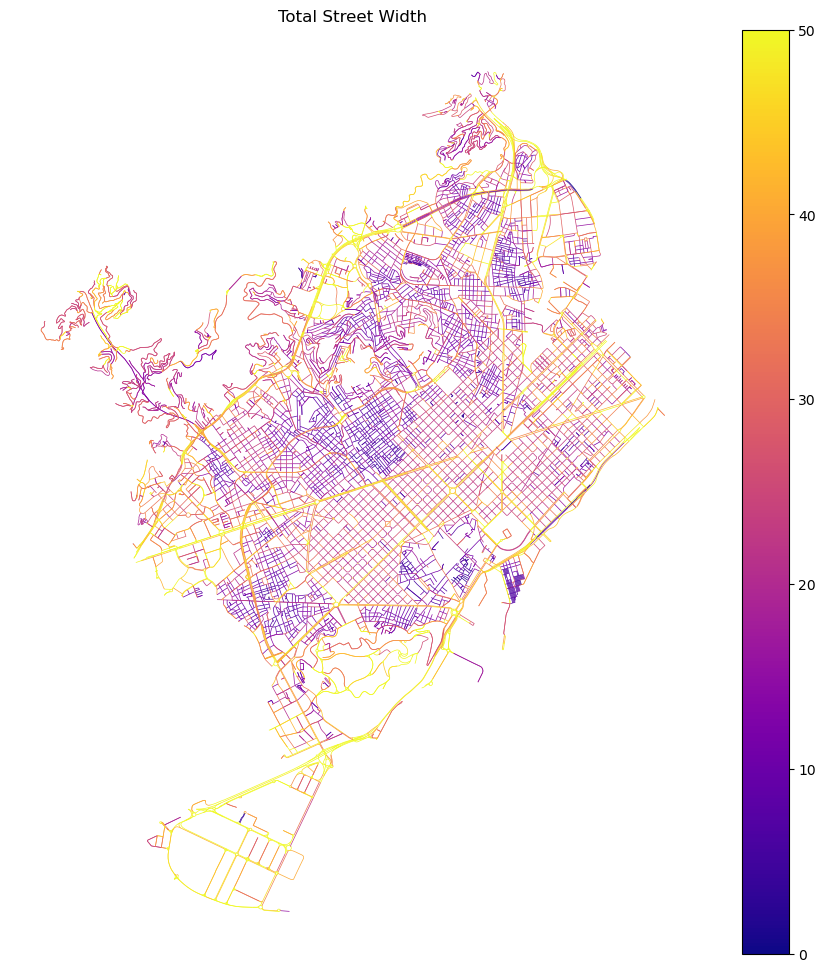

In [6]:
ax = edges.plot(cmap="plasma", column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

# Centrality

## Betweenness Centrality

In [7]:
primal = mm.gdf_to_nx(edges, approach="primal")

Careful, takes long

In [8]:
betweenness = mm.betweenness_centrality(
    primal, name="betweenness_metric_e", mode="edges", weight="mm_len"
)

In [9]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,est_width,tunnel,bridge,service,segment_id,geometry,openness,width_deviation,mm_len,betweenness_metric_e
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.750000,5.740353,28.292092,0.000896
1,21638845,13175411896,0,"[4079500, 1433594636, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,True,...,NaN,NaN,NaN,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.363095,5.540738,615.655095,0.002015
2,13175411896,21638845,0,"[1433594636, 4079500, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,False,...,NaN,NaN,NaN,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.339286,5.726241,615.655095,0.002015
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",1.000000,NaN,31.257819,0.000896
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.562500,0.594311,119.292946,0.000672


Text(0.5, 1.0, 'Betweenness Centrality (Edge Based)')

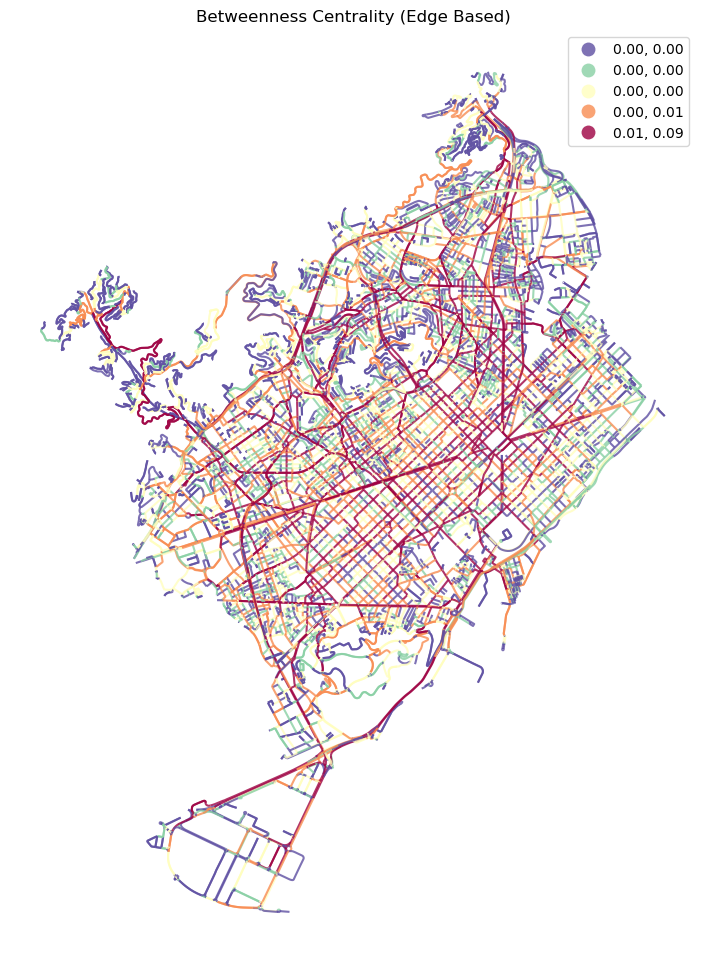

In [10]:
ax = primal_gdf_betw.plot(
    column="betweenness_metric_e",
    cmap="Spectral_r",
    scheme="quantiles",
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title("Betweenness Centrality (Edge Based)")

## Global Closenness Centrality

Careful, takes long

In [11]:
closeness = mm.closeness_centrality(
    primal, name="closeness_global", weight="mm_len"
)

In [12]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8924 entries, 0 to 8923
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   x                 8924 non-null   float64 
 1   y                 8924 non-null   float64 
 2   closeness_global  8924 non-null   float64 
 3   nodeID            8924 non-null   int64   
 4   geometry          8924 non-null   geometry
dtypes: float64(3), geometry(1), int64(1)
memory usage: 348.7 KB


Text(0.5, 1.0, 'Closenness Global (Node Based)')

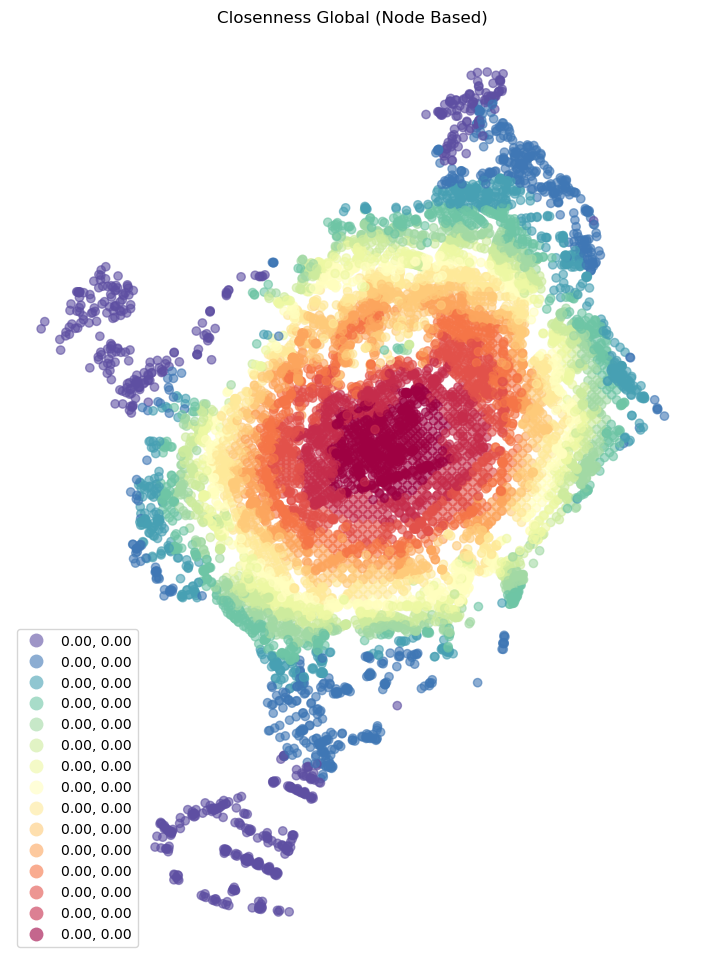

In [13]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [14]:
mm.mean_nodes(closeness, "closeness_global")

In [15]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,est_width,tunnel,bridge,service,segment_id,geometry,openness,width_deviation,mm_len,closeness_global
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.750000,5.740353,28.292092,0.000147
1,21638845,13175411896,0,"[4079500, 1433594636, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,True,...,NaN,NaN,NaN,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.363095,5.540738,615.655095,0.000154
2,13175411896,21638845,0,"[1433594636, 4079500, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,False,...,NaN,NaN,NaN,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.339286,5.726241,615.655095,0.000154
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",1.000000,NaN,31.257819,0.000147
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.562500,0.594311,119.292946,0.000145


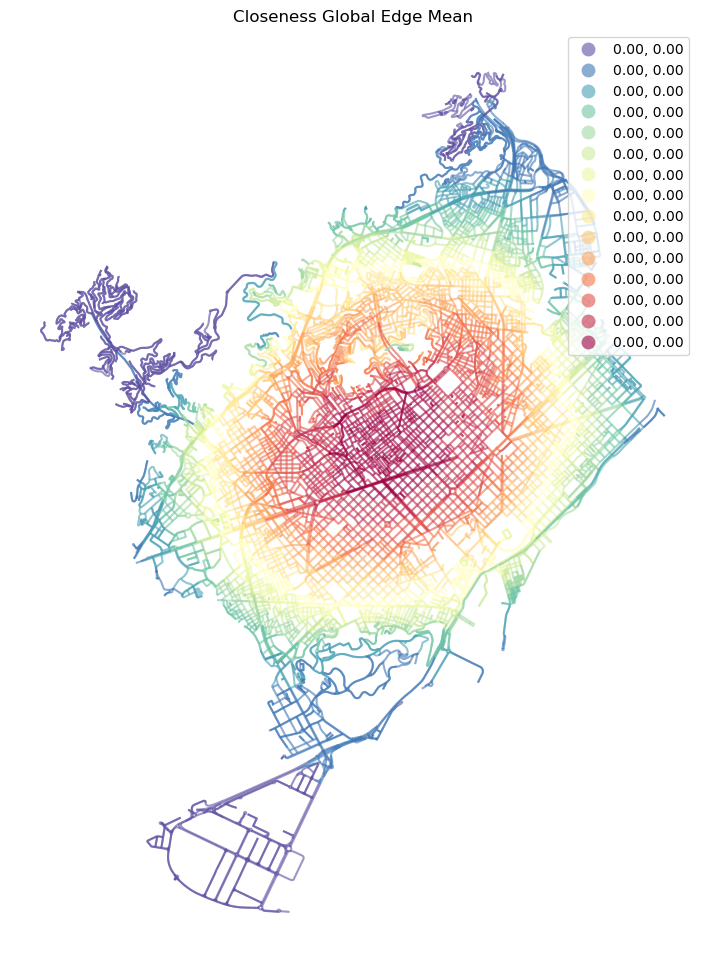

In [16]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

## Local Closeness Centrality

In [17]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name="closeness400", distance="mm_len", weight="mm_len"
)

  0%|          | 0/8924 [00:00<?, ?it/s]

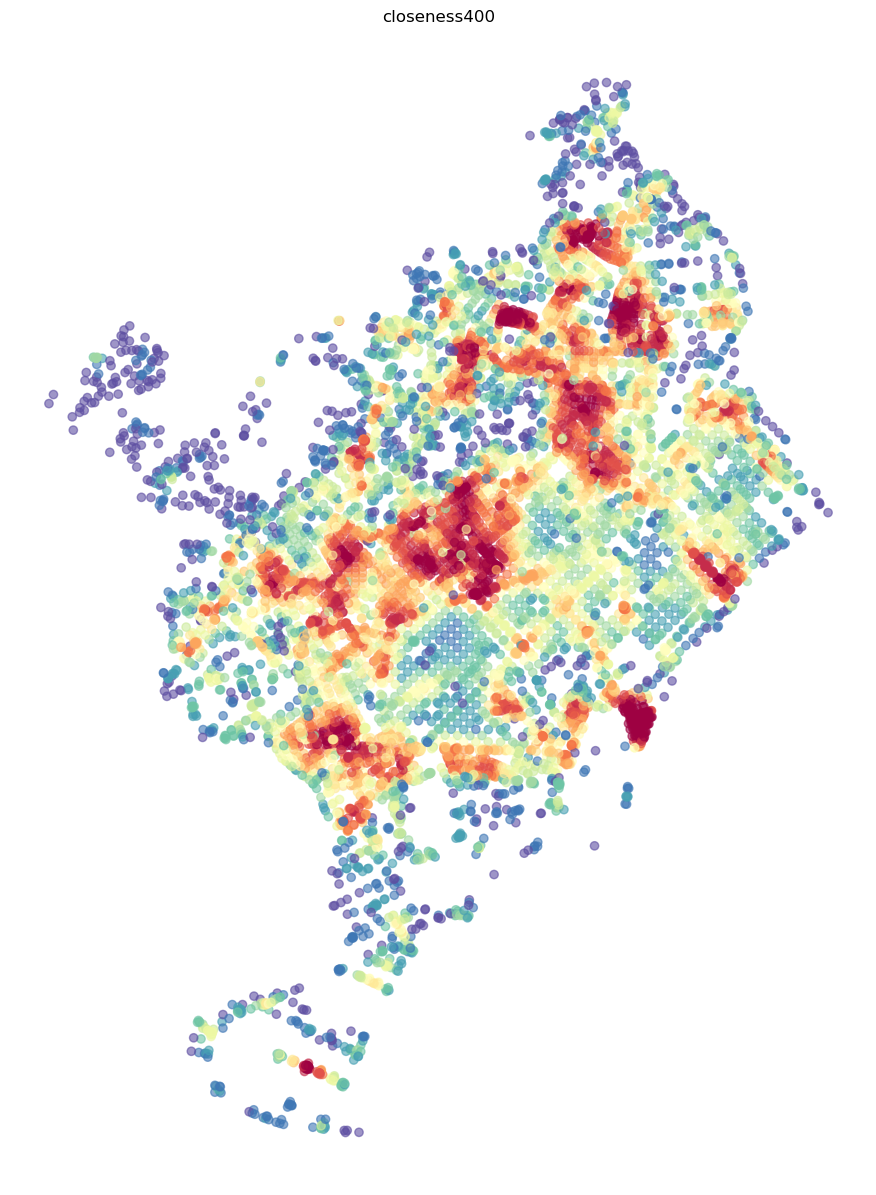

In [18]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

In [19]:
mm.mean_nodes(local_clos, "closeness400")

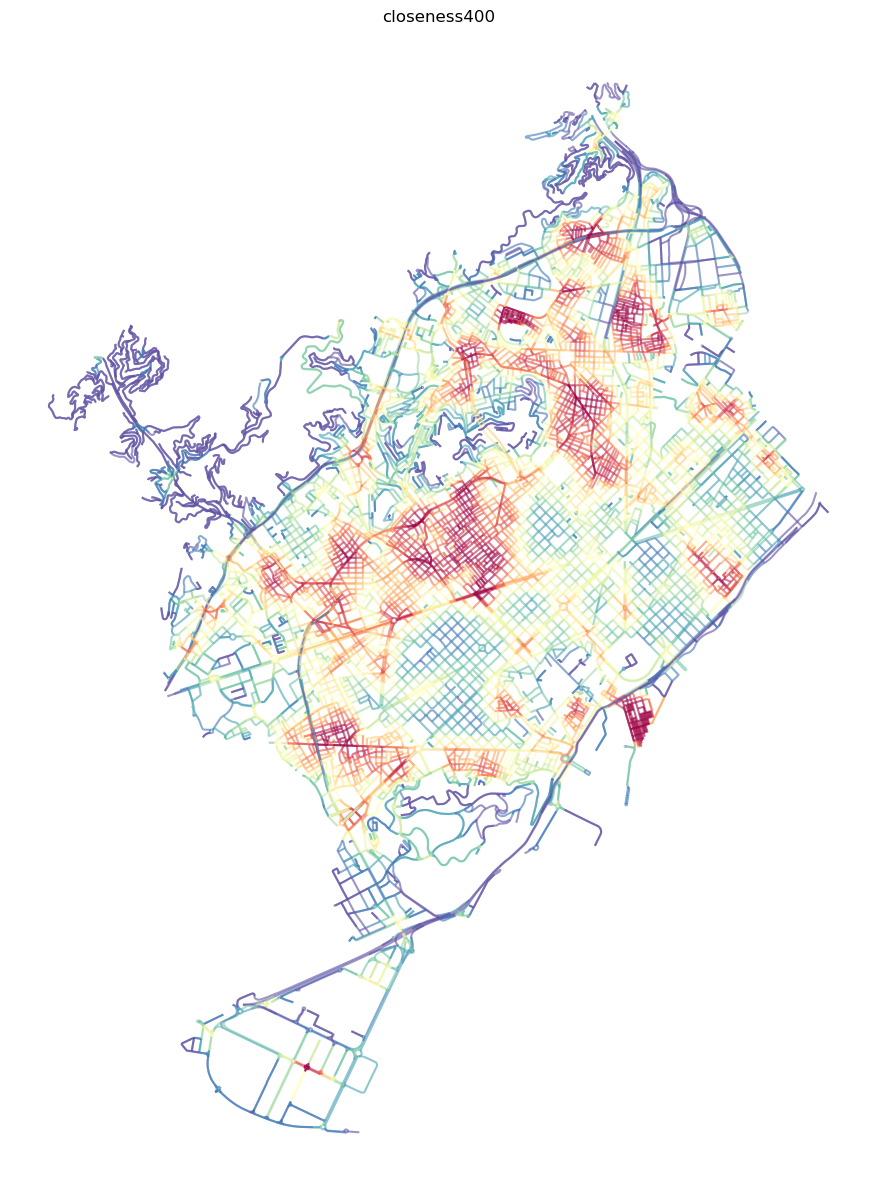

In [20]:
primal_gdf_clos400 = mm.nx_to_gdf(local_clos, points=False)

ax = primal_gdf_clos400.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

## Straightness

In [21]:
straighteness = mm.straightness_centrality(
    primal
)

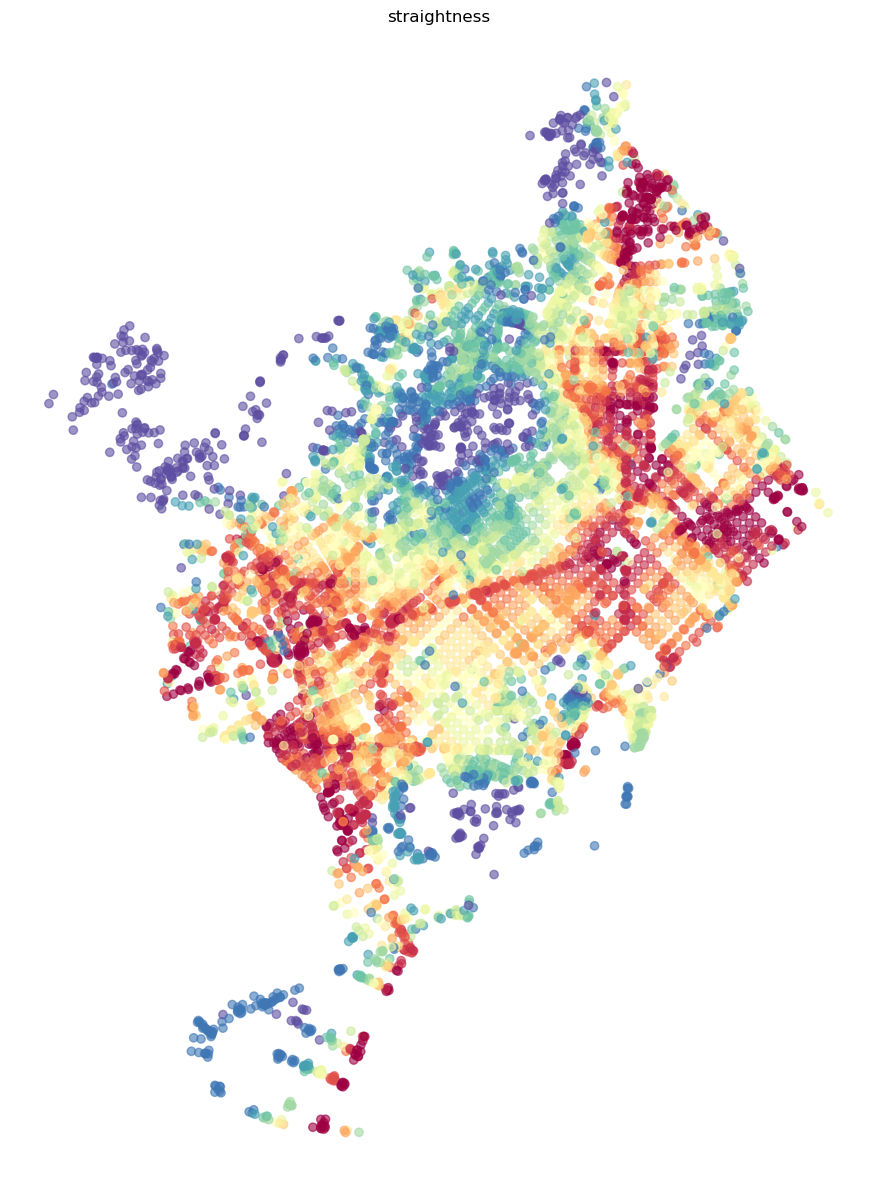

In [22]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [23]:
mm.mean_nodes(straighteness, "straightness")

In [24]:
primal_gdf_str = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_str.head()

,u,v,__key,osmid,highway,lanes,maxspeed,name,oneway,reversed,...,est_width,tunnel,bridge,service,segment_id,geometry,openness,width_deviation,mm_len,straightness
0,21638845,885308258,0,554707785,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,21638845_885308258_0,"LINESTRING (432071.186 4580160.408, 432067.928...",0.750000,5.740353,28.292092,0.798398
1,21638845,13175411896,0,"[4079500, 1433594636, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,True,...,NaN,NaN,NaN,NaN,21638845_13175411896_0,"LINESTRING (432071.186 4580160.408, 432066.515...",0.363095,5.540738,615.655095,0.812345
2,13175411896,21638845,0,"[1433594636, 4079500, 1522870832, 543357596, 9...",residential,"['4', '3']",30,Passeig de Joan de Borbó,False,False,...,NaN,NaN,NaN,NaN,13175411896_21638845_0,"LINESTRING (432176.044 4580757.599, 432174.921...",0.339286,5.726241,615.655095,0.812345
3,885308314,21638845,0,554707788,residential,2,30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,885308314_21638845_0,"LINESTRING (432087.076 4580133.49, 432071.186 ...",1.000000,NaN,31.257819,0.798799
4,885308258,885308166,0,"[74975048, 214435425]",residential,"['1', '2']",30,Passeig de Joan de Borbó,True,False,...,NaN,NaN,NaN,NaN,885308258_885308166_0,"LINESTRING (432067.928 4580132.304, 432066.177...",0.562500,0.594311,119.292946,0.796396


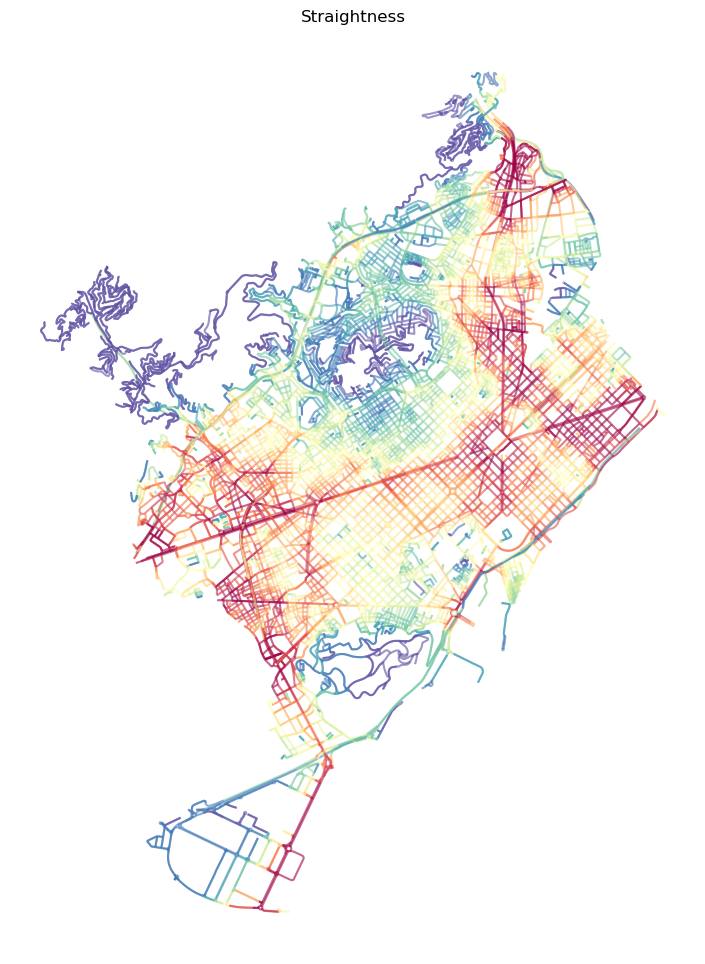

In [25]:

ax = primal_gdf_str.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Straightness")

## Create data frame

In [26]:
dataset = edges[['segment_id', 'width', 'openness']].copy()

dataset = (
    dataset
    .merge(primal_gdf_betw[['segment_id', 'betweenness_metric_e']], on='segment_id', how='left')
    .merge(primal_gdf_clos[['segment_id', 'closeness_global']], on='segment_id', how='left')
    .merge(primal_gdf_clos400[['segment_id', 'closeness400']], on='segment_id', how='left')
    .merge(primal_gdf_str[['segment_id', 'straightness']], on='segment_id', how='left')
    .rename(columns={
        'segment_id': 'road_id',
        'betweenness_metric_e': 'betweenness',
        'closeness400': 'closeness_400'
    })
    .fillna(0)
)

dataset.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,21638845_885308258_0,43.025602,0.750000,0.000896,0.000147,0.000006,0.798398
1,21638845_13175411896_0,26.114886,0.363095,0.002015,0.000154,0.000011,0.812345
2,21638865_30343650_0,15.135908,0.750000,0.000224,0.000161,0.000031,0.822206
3,21638867_1636238503_0,18.154330,0.666667,0.002529,0.000168,0.000048,0.831058
4,21638867_1403082237_0,20.158620,0.666667,0.002416,0.000168,0.000050,0.829978


## Export dataset to CSV

In [27]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_roads_features.csv"), index=False)
print("Exported momepy_roads_features.csv")

Exported momepy_roads_features.csv
